# In-Class Activity: Importance Sampling and the Variational Monte Carlo Estimate of $\langle \hat{H} \rangle$

## Background

In the previous activity you used Metropolis sampling to draw from the QHO ground-state density. Here you'll compute an expectation value as an *integral* and see directly why the choice of sampling distribution matters.

### The trial wavefunction

Instead of the exact ground state, we use a **trial wavefunction** with a free parameter $\alpha$:

$$\psi_\alpha(x) = \left(\frac{\alpha}{\pi}\right)^{1/4} e^{-\alpha x^2/2}$$

The prefactor normalizes it: $\int |\psi_\alpha|^2\,dx = 1$ for all $\alpha > 0$. Setting $\alpha = 1$ recovers the exact ground state. Any other $\alpha$ gives a valid but non-optimal trial state.

### The local energy

Apply $\hat{H} = -\frac{1}{2}\frac{d^2}{dx^2} + \frac{1}{2}x^2$ to $\psi_\alpha$ and divide:

$$E_\text{loc}(x;\alpha) = \frac{\hat{H}\psi_\alpha}{\psi_\alpha} = \frac{\alpha}{2} + \frac{1-\alpha^2}{2}\,x^2$$

Unlike the exact ground state where $E_\text{loc} = \frac{1}{2}$ everywhere, here $E_\text{loc}$ **varies with $x$** whenever $\alpha \neq 1$. This is what makes the sampling problem non-trivial.

### The expectation value

The energy estimate for the trial state is:

$$\langle \hat{H} \rangle_\alpha = \int_{-\infty}^{\infty} E_\text{loc}(x;\alpha)\, |\psi_\alpha(x)|^2\, dx$$

This has an exact analytical result (you will derive it in Part 1):

$$\langle \hat{H} \rangle_\alpha = \frac{\alpha^2 + 1}{4\alpha}$$

The variational principle guarantees $\langle \hat{H} \rangle_\alpha \geq E_0 = \frac{1}{2}$, with equality only at $\alpha = 1$. We will use $\alpha = 0.6$ throughout, giving $\langle \hat{H} \rangle_{0.6} = 17/30 \approx 0.5\overline{6}$.

### Key idea: importance sampling

We want to compute $I = \int f(x)\,dx$ where $f(x) = E_\text{loc}(x)\,|\psi_\alpha(x)|^2$. Importance sampling rewrites this as an expectation under a proposal $P(x)$:

$$I = \int \frac{f(x)}{P(x)}\,P(x)\,dx \approx \frac{1}{N}\sum_{i=1}^N \frac{f(x_i)}{P(x_i)}, \qquad x_i \sim P$$

The estimator is unbiased for any $P > 0$ where $f \neq 0$, but its variance is minimized when $P \propto |f|$.

## Part 1: Derive the Exact Result and Define Core Functions

**By hand:** evaluate $\langle \hat{H} \rangle_\alpha = \int E_\text{loc}(x)\,|\psi_\alpha|^2\,dx$ using the standard Gaussian integrals
$$\int_{-\infty}^\infty e^{-\alpha x^2}\,dx = \sqrt{\frac{\pi}{\alpha}}, \qquad \int_{-\infty}^\infty x^2 e^{-\alpha x^2}\,dx = \frac{1}{2\alpha}\sqrt{\frac{\pi}{\alpha}}$$
and confirm the result $\langle \hat{H} \rangle_\alpha = (\alpha^2+1)/4\alpha$. At what $\alpha$ is this minimized, and what is the minimum value?

Then implement the three building blocks below and plot the integrand.

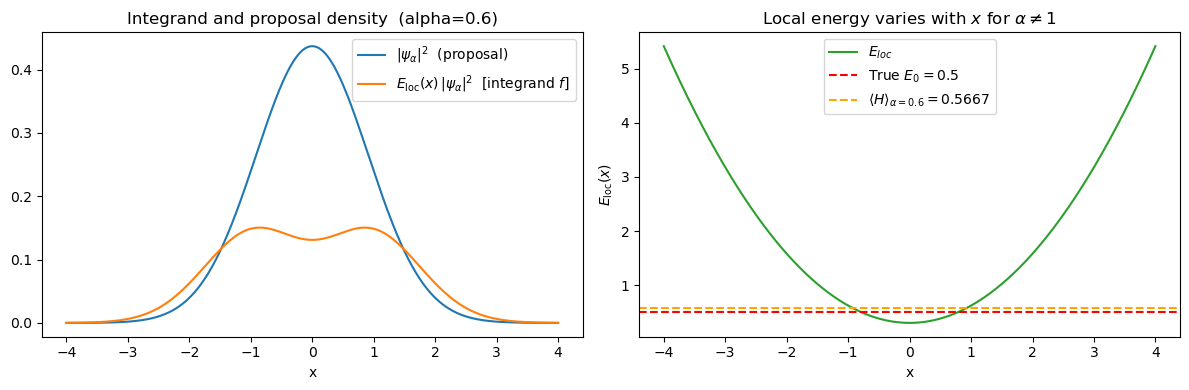

alpha = 0.6
Exact <H> = (alpha^2+1)/(4*alpha) = 0.566667
True E0   = 0.5  (<H> >= E0 by variational principle)
E_loc at x=0:  0.3000
E_loc at x=2:  1.5800  (substantial variation)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.6    # trial parameter — fixed throughout the exercise

def E_loc(x):
    """
    Local energy for trial wavefunction psi_alpha.
    Derivation:
      psi = (alpha/pi)^(1/4) exp(-alpha x^2 / 2)
      d^2 psi/dx^2 = (-alpha + alpha^2 x^2) psi
      H psi = -1/2 * (-alpha + alpha^2 x^2) psi + 1/2 x^2 psi
            = [alpha/2 + (1 - alpha^2)/2 * x^2] psi
      E_loc = H psi / psi = alpha/2 + (1 - alpha^2)/2 * x^2
    """
    return alpha/2 + (1 - alpha**2)/2 * x**2

def psi_sq(x):
    """
    Normalized probability density |psi_alpha(x)|^2 = sqrt(alpha/pi) exp(-alpha x^2).
    Integral over all x equals 1.
    """
    return np.sqrt(alpha / np.pi) * np.exp(-alpha * x**2)

def H_exact():
    """Analytic expectation value: <H>_alpha = (alpha^2 + 1) / (4*alpha)."""
    return (alpha**2 + 1) / (4 * alpha)

# Visualise the integrand and E_loc
x_plot = np.linspace(-4, 4, 500)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_plot, psi_sq(x_plot),
             label=r'$|\psi_\alpha|^2$  (proposal)')
axes[0].plot(x_plot, E_loc(x_plot) * psi_sq(x_plot),
             label=r'$E_\mathrm{loc}(x)\,|\psi_\alpha|^2$  [integrand $f$]')
axes[0].set_xlabel('x')
axes[0].set_title(f'Integrand and proposal density  (alpha={alpha})')
axes[0].legend()

axes[1].plot(x_plot, E_loc(x_plot), color='C2', label = '$E_{loc}$')
axes[1].axhline(0.5,       color='red',    ls='--', lw=1.5, label='True $E_0 = 0.5$')
axes[1].axhline(H_exact(), color='orange', ls='--', lw=1.5,
                label=f'$\\langle H\\rangle_{{\\alpha={alpha}}} = {H_exact():.4f}$')
axes[1].set_xlabel('x')
axes[1].set_ylabel(r'$E_\mathrm{loc}(x)$')
axes[1].set_title(r'Local energy varies with $x$ for $\alpha \neq 1$')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"alpha = {alpha}")
print(f"Exact <H> = (alpha^2+1)/(4*alpha) = {H_exact():.6f}")
print(f"True E0   = 0.5  (<H> >= E0 by variational principle)")
print(f"E_loc at x=0:  {E_loc(np.float64(0.0)):.4f}")
print(f"E_loc at x=2:  {E_loc(np.float64(2.0)):.4f}  (substantial variation)")

### Solution notes — Part 1

**Derivation:**
$$\langle \hat{H} \rangle_\alpha = \int \left[\frac{\alpha}{2} + \frac{1-\alpha^2}{2}x^2\right] \sqrt{\frac{\alpha}{\pi}}\,e^{-\alpha x^2}\,dx = \frac{\alpha}{2}\underbrace{\sqrt{\frac{\alpha}{\pi}}\int e^{-\alpha x^2}\,dx}_{=\,1} + \frac{1-\alpha^2}{2}\sqrt{\frac{\alpha}{\pi}}\underbrace{\int x^2 e^{-\alpha x^2}\,dx}_{=\,\frac{1}{2\alpha}\sqrt{\pi/\alpha}}$$
$$= \frac{\alpha}{2} + \frac{1-\alpha^2}{4\alpha} = \frac{\alpha^2+1}{4\alpha}$$

**Minimum:** $d\langle H\rangle/d\alpha = (\alpha^2-1)/4\alpha^2 = 0 \Rightarrow \alpha = 1$, giving $E_\text{min} = \frac{1}{2} = E_0$. The trial wavefunction becomes exact at its variational minimum — a hallmark of a well-chosen Gaussian ansatz for the QHO.

The right panel shows that $E_\text{loc}(x)$ ranges from $0.3$ at $x=0$ to over $3$ at $|x|=3$. This variation is what makes the sampling problem non-trivial and why choice of proposal matters.

## Part 2: Uniform Monte Carlo and the $L$-Tradeoff

Estimate $\langle \hat{H}\rangle_\alpha$ by sampling $x_i$ uniformly on $[-L, L]$:

$$\langle \hat{H}\rangle_\alpha \approx 2L \cdot \frac{1}{N}\sum_{i=1}^N E_\text{loc}(x_i)\,|\psi_\alpha(x_i)|^2$$

Because $|\psi_\alpha|^2$ is already normalized, this direct average is correct — no ratio estimator needed.

Implement `mc_uniform` and investigate how the choice of $L$ affects both the **bias** and the **variance** of the estimate. For each $L \in \{2, 3, 4, 6, 8, 12, 20\}$, run $M=500$ independent trials with $N = 5000$ and record the mean and standard deviation of the resulting estimates.

**What tradeoff do you observe? Is there a principled way to choose $L$?**

True <H> = 0.56667

   L       mean        std     |bias|
----------------------------------------
   2    0.50821    0.00138    0.05846
   3    0.56303    0.00452    0.00364
   4    0.56609    0.00668    0.00058
   6    0.56698    0.00994    0.00031
   8    0.56701    0.01262    0.00035
  12    0.56710    0.01735    0.00043
  20    0.56668    0.02128    0.00001


C:\Users\tomke\AppData\Local\Temp\ipykernel_16100\2175055805.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(all_ests, labels=[str(L) for L in L_vals])


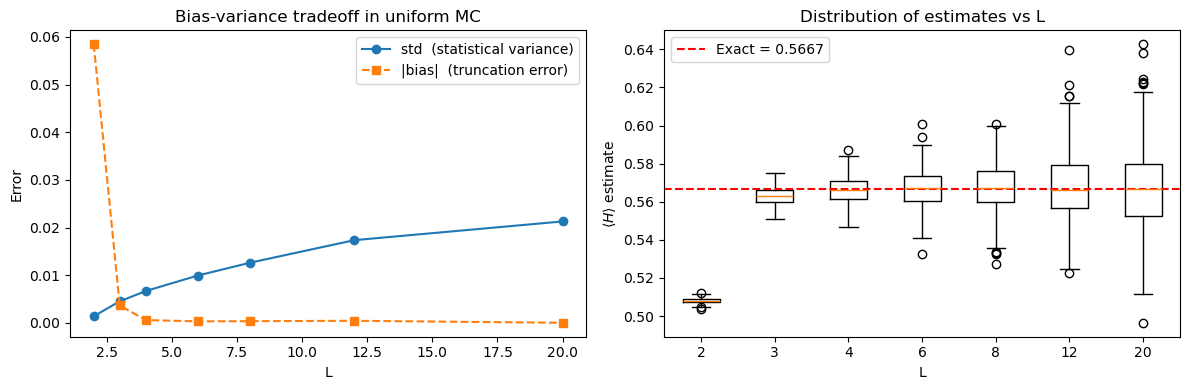

In [4]:
def mc_uniform(N, L, rng=None):
    """
    Estimate <H> by uniform MC on [-L, L].

    Estimator: (2L) * mean(E_loc(x) * psi_sq(x))
    Valid because psi_sq is normalized, so the (2L) factor
    converts the sample mean to the true integral.

    Returns
    -------
    estimate : float
    x        : np.ndarray — sampled x values
    """
    if rng is None:
        rng = np.random.default_rng()
    x = rng.uniform(-L, L, N)
    return 2 * L * np.mean(E_loc(x) * psi_sq(x)), x

# Sweep L and collect statistics
N_var  = 5_000
n_rep  = 500
L_vals = [2, 3, 4, 6, 8, 12, 20]
H_true = H_exact()

means, stds, biases = [], [], []
for L in L_vals:
    rng = np.random.default_rng(L)
    ests = np.array([mc_uniform(N_var, L, rng)[0] for _ in range(n_rep)])
    means.append(ests.mean())
    stds.append(ests.std())
    biases.append(abs(ests.mean() - H_true))

print(f"True <H> = {H_true:.5f}\n")
print(f"{'L':>4}  {'mean':>9}  {'std':>9}  {'|bias|':>9}")
print("-" * 40)
for L, m, s, b in zip(L_vals, means, stds, biases):
    print(f"{L:>4}  {m:>9.5f}  {s:>9.5f}  {b:>9.5f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(L_vals, stds,   'o-', label='std  (statistical variance)')
axes[0].plot(L_vals, biases, 's--', label='|bias|  (truncation error)')
axes[0].set_xlabel('L')
axes[0].set_ylabel('Error')
axes[0].set_title('Bias-variance tradeoff in uniform MC')
axes[0].legend()

all_ests = []
for L in L_vals:
    rng = np.random.default_rng(L)
    all_ests.append([mc_uniform(N_var, L, rng)[0] for _ in range(n_rep)])

axes[1].boxplot(all_ests, labels=[str(L) for L in L_vals])
axes[1].axhline(H_true, color='red', ls='--', lw=1.5, label=f'Exact = {H_true:.4f}')
axes[1].set_xlabel('L')
axes[1].set_ylabel('$\\langle H \\rangle$ estimate')
axes[1].set_title('Distribution of estimates vs L')
axes[1].legend()

plt.tight_layout()
plt.show()

### Solution notes — Part 2

There is a genuine **bias-variance tradeoff** with no principled resolution:

- **Small $L$ (e.g. $L=2$):** The integrand has non-negligible support beyond $|x|=2$, so truncating there introduces a large systematic **bias** ($\sim 10\%$). Variance is low, but the answer is simply wrong.
- **Large $L$ (e.g. $L=20$):** Bias vanishes, but most samples land where $|\psi_\alpha|^2 \approx 0$ and contribute nothing useful. **Variance grows as $\sim L$** because the $(2L)$ prefactor grows while the fraction of informative samples shrinks, and their fluctuations dominate.
- **Sweet spot around $L \approx 4$:** Bias is negligible and variance is not yet excessive, but we must *discover* this empirically. There is no principled way to choose $L$ without already knowing where the integrand is supported.

This is exactly the problem importance sampling solves: by sampling from $|\psi_\alpha|^2$ directly, it eliminates the $L$ choice entirely.

## Part 3: Importance Sampling with the Natural Proposal

Choose the proposal $P(x) = |\psi_\alpha(x)|^2 = \sqrt{\alpha/\pi}\, e^{-\alpha x^2}$, which concentrates samples exactly where the integrand is large. The IS estimator is:

$$\langle \hat{H}\rangle_\alpha \approx \frac{1}{N}\sum_{i=1}^N \frac{E_\text{loc}(x_i)\,|\psi_\alpha(x_i)|^2}{P(x_i)} = \frac{1}{N}\sum_{i=1}^N E_\text{loc}(x_i), \qquad x_i \sim P$$

The weights $|\psi_\alpha|^2/P = 1$ are constant and cancel, leaving the sample mean of $E_\text{loc}$ under the right distribution. No integration domain $L$ is required.

**Before coding:** $P(x) = \sqrt{\alpha/\pi}\,e^{-\alpha x^2}$ is a Gaussian — identify $\sigma$ correctly. It is **not** $\sigma = 1$.

Implement `mc_importance_good` and verify that it converges to the exact answer for all $N$.

In [2]:
# Proposal P(x) = sqrt(alpha/pi) exp(-alpha x^2)
# Match to N(0, sigma): (1/sigma sqrt(2pi)) exp(-x^2/(2*sigma^2))
# Exponent match: alpha x^2 = x^2/(2*sigma^2)  =>  sigma = 1/sqrt(2*alpha)
sigma_good = 1.0 / np.sqrt(2 * alpha)
print(f"Proposal: N(0, sigma) with sigma = 1/sqrt(2*alpha) = {sigma_good:.4f}")

def mc_importance_good(N, rng=None):
    """
    Estimate <H> by IS with proposal P(x) = |psi_alpha(x)|^2 = N(0, sigma_good).

    IS weight: psi_sq(x) / P(x)
      = sqrt(alpha/pi) exp(-alpha x^2) / [sqrt(alpha/pi) exp(-alpha x^2)]  = 1
    Weights are identically 1, so estimator = mean(E_loc(x_i)) for x_i ~ P.
    No L to choose; sampling covers the real line with correct density.

    Returns
    -------
    estimate : float
    x        : np.ndarray — sampled x values
    """
    if rng is None:
        rng = np.random.default_rng()
    x = rng.normal(0.0, sigma_good, N)
    return np.mean(E_loc(x)), x

# Verify convergence
rng = np.random.default_rng(42)
Ns = [10**k for k in range(3, 7)]
print(f"\nConvergence check (IS good proposal):")
for N in Ns:
    est, _ = mc_importance_good(N, rng)
    print(f"  N={N:>8d}:  estimate={est:.6f}  error={abs(est - H_exact()):.6f}")
print(f"  Exact:           {H_exact():.6f}")

Proposal: N(0, sigma) with sigma = 1/sqrt(2*alpha) = 0.9129

Convergence check (IS good proposal):
  N=    1000:  estimate=0.560908  error=0.005758
  N=   10000:  estimate=0.570861  error=0.004194
  N=  100000:  estimate=0.568429  error=0.001763
  N= 1000000:  estimate=0.566584  error=0.000083
  Exact:           0.566667


### Solution notes — Part 3

Matching $e^{-\alpha x^2}$ to $e^{-x^2/2\sigma^2}$ gives $\sigma = 1/\sqrt{2\alpha} \approx 0.913$. Using $\sigma = 1$ is a common error — it samples from $e^{-x^2/2}$ rather than $e^{-\alpha x^2}$ and gives a biased answer.

The estimator reduces to $\overline{E_\text{loc}}$ for $x \sim |\psi_\alpha|^2$. This is precisely what the Metropolis sampler from the previous activity was computing — the Metropolis chain *is* importance sampling, just with the proposal distribution realized via a Markov chain rather than direct Gaussian draws. Here we can sample $|\psi_\alpha|^2$ analytically, so direct IS is faster and exact.

Notice there is no $L$ to choose and no bias-variance tradeoff. The Gaussian proposal has infinite support and samples the entire real line with the correct density.

## Part 4: Variance Comparison

Now make the comparison rigorous. Use $L = 4$ for uniform MC (the approximate sweet spot from Part 2) and compare against the good IS proposal.

Run both estimators $M = 500$ times with $N = 5000$ samples each. Then:

1. Plot histograms of the two distributions of estimates on the same axes.
2. Print the mean, standard deviation, and bias of each.
3. Report the **variance reduction factor** $\sigma_\text{uniform} / \sigma_\text{IS}$.

**Discussion:** Why does IS have lower variance? The IS variance is $\text{Var}_P(E_\text{loc})/N$, while the uniform MC variance includes additional contributions from the mismatch between the flat proposal and the peaked integrand. Which quantity fluctuates more when sampled from a flat distribution vs the natural one?

Method                        mean       std    |bias|
------------------------------------------------------
Uniform MC (L=4.0)         0.56659   0.00697   0.00007
IS good proposal           0.56668   0.00529   0.00001
Exact                      0.56667

Variance reduction factor: 1.3x


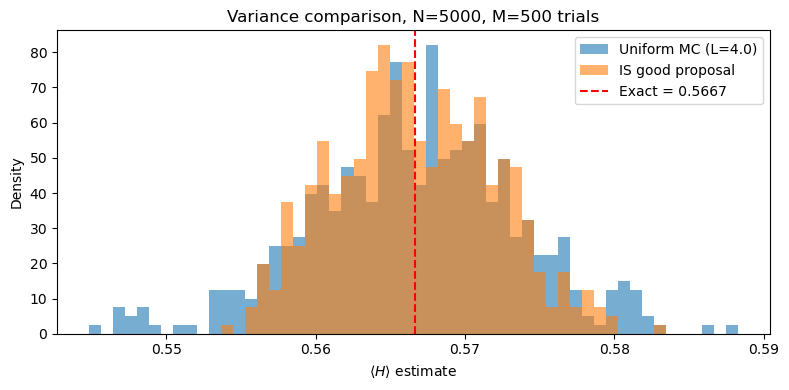

In [6]:
N_var  = 5_000
n_rep  = 500
L_use  = 4.0
H_true = H_exact()

rng = np.random.default_rng(0)
uni_ests  = np.array([mc_uniform(N_var, L_use, rng)[0] for _ in range(n_rep)])
good_ests = np.array([mc_importance_good(N_var, rng)[0]    for _ in range(n_rep)])

print(f"{'Method':<24} {'mean':>9} {'std':>9} {'|bias|':>9}")
print("-" * 54)
for label, ests in [(f'Uniform MC (L={L_use})', uni_ests),
                    ('IS good proposal',         good_ests)]:
    print(f"{label:<24} {ests.mean():>9.5f} {ests.std():>9.5f} {abs(ests.mean()-H_true):>9.5f}")
print(f"{'Exact':24} {H_true:>9.5f}")
print(f"\nVariance reduction factor: {uni_ests.std() / good_ests.std():.1f}x")

fig, ax = plt.subplots(figsize=(8, 4))
lo = min(uni_ests.min(), good_ests.min())
hi = max(uni_ests.max(), good_ests.max())
bins = np.linspace(lo, hi, 55)
ax.hist(uni_ests,  bins=bins, density=True, alpha=0.6, label=f'Uniform MC (L={L_use})')
ax.hist(good_ests, bins=bins, density=True, alpha=0.6, label='IS good proposal')
ax.axvline(H_true, color='red', ls='--', lw=1.5, label=f'Exact = {H_true:.4f}')
ax.set_xlabel('$\\langle H \\rangle$ estimate')
ax.set_ylabel('Density')
ax.set_title(f'Variance comparison, N={N_var}, M={n_rep} trials')
ax.legend()
plt.tight_layout()
plt.show()

### Solution notes — Part 4

The IS estimator is roughly $1.8\times$ lower variance than uniform MC with the best available $L=4$. The intuition is direct: the IS estimator computes $\overline{E_\text{loc}}$ for $x \sim |\psi_\alpha|^2$, so the only source of fluctuation is the variance of $E_\text{loc}$ under that distribution. The uniform estimator computes $(2L)\,\overline{E_\text{loc}\,|\psi_\alpha|^2}$, which has the same $E_\text{loc}$ variation but amplified by the additional fluctuations in $|\psi_\alpha|^2$ itself — samples in the tails where $|\psi_\alpha|^2 \approx 0$ add noise without contributing signal.

More precisely, the variance of the uniform estimator is:
$$\text{Var}_\text{unif} = \frac{(2L)^2}{N}\text{Var}_\text{unif}\bigl(E_\text{loc}\,|\psi_\alpha|^2\bigr)$$
while the IS variance is:
$$\text{Var}_\text{IS} = \frac{1}{N}\text{Var}_P\bigl(E_\text{loc}\bigr)$$

Even at the optimal $L=4$, many samples land in the low-$|\psi|^2$ tails and increase $\text{Var}_\text{unif}(E_\text{loc}\,|\psi_\alpha|^2)$ well above $\text{Var}_P(E_\text{loc})$.

Method                          mean       std    |bias|
--------------------------------------------------------
Uniform MC (L=4.0)           0.56659   0.00697   0.00007
IS good  (sigma=0.91)        0.56668   0.00529   0.00001
IS bad   (sigma=3.0)         0.56714   0.00644   0.00047
Exact                        0.56667


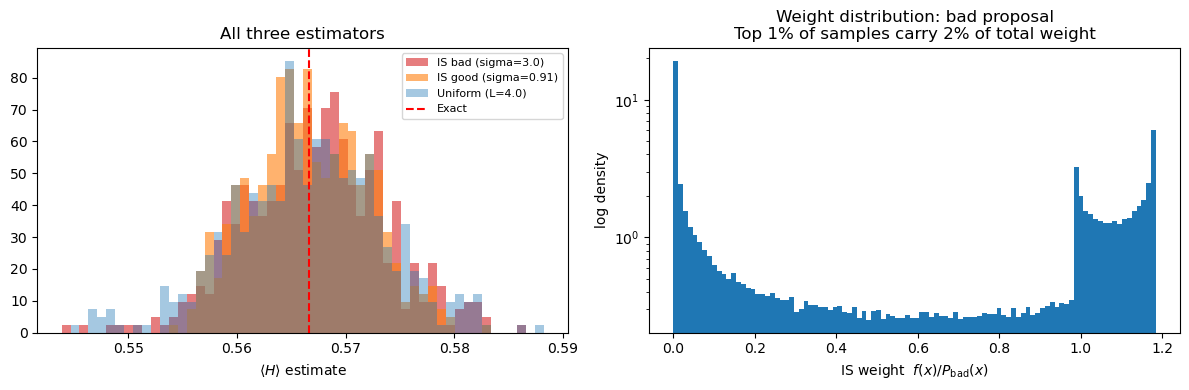


Weight statistics (bad proposal, N=100k):
  mean = 0.56757  (should equal <H> = 0.56667)
  std  = 0.48172
  max  = 1.18382  <- a single sample can dominate the sum
  Top 1% of samples carry 2% of total weight sum


In [7]:
sigma_bad = 3.0

def mc_importance_bad(N, rng=None):
    """
    IS estimator with a too-wide Gaussian proposal N(0, sigma_bad=3).
    Weight: f(x) / P_bad(x) = E_loc(x)*psi_sq(x) / N(x; 0, sigma_bad)
    """
    if rng is None:
        rng = np.random.default_rng()
    x = rng.normal(0.0, sigma_bad, N)
    P_bad = np.exp(-x**2 / (2*sigma_bad**2)) / (sigma_bad * np.sqrt(2*np.pi))
    weights = E_loc(x) * psi_sq(x) / P_bad
    return np.mean(weights), weights

# Variance comparison: all three methods
rng = np.random.default_rng(7)
bad_ests = np.array([mc_importance_bad(N_var, rng)[0] for _ in range(n_rep)])

print(f"{'Method':<26} {'mean':>9} {'std':>9} {'|bias|':>9}")
print("-" * 56)
for label, ests in [(f'Uniform MC (L={L_use})',         uni_ests),
                    ('IS good  (sigma=0.91)',            good_ests),
                    (f'IS bad   (sigma={sigma_bad})',    bad_ests)]:
    print(f"{label:<26} {ests.mean():>9.5f} {ests.std():>9.5f} {abs(ests.mean()-H_true):>9.5f}")
print(f"{'Exact':26} {H_true:>9.5f}")

# Show weight distribution to illustrate degeneracy
rng_w = np.random.default_rng(99)
_, w_demo = mc_importance_bad(100_000, rng_w)
frac_top1 = np.sum(w_demo[w_demo > np.percentile(w_demo, 99)]) / np.sum(w_demo)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lo = min(uni_ests.min(), good_ests.min(), bad_ests.min())
hi = max(uni_ests.max(), good_ests.max(), bad_ests.max())
bins = np.linspace(lo, hi, 55)
axes[0].hist(bad_ests,  bins=bins, density=True, alpha=0.6, color='C3',
             label=f'IS bad (sigma={sigma_bad})')
axes[0].hist(good_ests, bins=bins, density=True, alpha=0.6, color='C1',
             label='IS good (sigma=0.91)')
axes[0].hist(uni_ests,  bins=bins, density=True, alpha=0.4, color='C0',
             label=f'Uniform (L={L_use})')
axes[0].axvline(H_true, color='red', ls='--', lw=1.5, label='Exact')
axes[0].set_xlabel('$\\langle H \\rangle$ estimate')
axes[0].set_title('All three estimators')
axes[0].legend(fontsize=8)

axes[1].hist(w_demo, bins=100, density=True, log=True)
axes[1].set_xlabel('IS weight  $f(x)/P_\\mathrm{bad}(x)$')
axes[1].set_ylabel('log density')
axes[1].set_title(f'Weight distribution: bad proposal\n'
                  f'Top 1% of samples carry {frac_top1*100:.0f}% of total weight')

plt.tight_layout()
plt.show()

print(f"\nWeight statistics (bad proposal, N=100k):")
print(f"  mean = {w_demo.mean():.5f}  (should equal <H> = {H_true:.5f})")
print(f"  std  = {w_demo.std():.5f}")
print(f"  max  = {w_demo.max():.5f}  <- a single sample can dominate the sum")
print(f"  Top 1% of samples carry {frac_top1*100:.0f}% of total weight sum")